# Football Player Position Prediction Pipeline
Comprehensive notebook combining data cleaning, feature engineering, and model training with detailed output visualization

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time
import unidecode
import re
import warnings

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, RobustScaler
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')

print("[Libraries] All required packages imported successfully")
print(f"  pandas {pd.__version__}")
print(f"  numpy {np.__version__}")
print(f"  scikit-learn ready")

[Libraries] All required packages imported successfully
  pandas 2.3.3
  numpy 2.3.5
  scikit-learn ready


## 2. Data Cleaning and Preparation

In [2]:
# Load raw data with encoding handling
file_path = 'neo4j_query_table_data_2025-11-27.csv'

try:
    df = pd.read_csv(file_path, encoding='utf-8')
    print("[Data Loading] UTF-8 encoding successful")
except UnicodeDecodeError:
    print("[Data Loading] UTF-8 failed, attempting Latin-1...")
    df = pd.read_csv(file_path, encoding='latin-1')
    print("[Data Loading] Latin-1 encoding successful")

print(f"[Dataset] {len(df)} rows, {len(df.columns)} columns")
print(f"[Columns] {', '.join(df.columns.tolist())}")

[Data Loading] UTF-8 encoding successful
[Dataset] 5000 rows, 12 columns
[Columns] full_name, positions, overall_rating, age, acceleration, sprint_speed, dribbling, short_passing, finishing, stamina, strength, embedding

[Dataset] 5000 rows, 12 columns
[Columns] full_name, positions, overall_rating, age, acceleration, sprint_speed, dribbling, short_passing, finishing, stamina, strength, embedding


In [3]:
# Define cleaning function
def clean_text(text):
    """Clean text by removing accents, special characters, and extra spaces"""
    if not isinstance(text, str):
        return text
    
    # Convert accents to regular characters
    text = unidecode.unidecode(text)
    
    # Keep only alphanumeric, spaces, dots, commas, and hyphens
    text = re.sub(r'[^a-zA-Z0-9\s\.,\-]', '', text)
    
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Clean player names and positions
print("[Data Cleaning] Processing player names...")
df['full_name'] = df['full_name'].apply(clean_text)

print("[Data Cleaning] Processing positions...")
df['positions'] = df['positions'].apply(lambda x: clean_text(x) if isinstance(x, str) else x)

# Extract primary position
df['primary_position'] = df['positions'].apply(lambda x: x.split(',')[0] if isinstance(x, str) else x)

print("[Data Cleaning] Completed\n")
print("Sample of cleaned data:")
print(df[['full_name', 'positions', 'primary_position']].head(5))

[Data Cleaning] Processing player names...
[Data Cleaning] Processing positions...
[Data Cleaning] Completed

Sample of cleaned data:
                        full_name  positions primary_position
0  Lionel Andres Messi Cuccittini   CF,RW,ST               CF
1     Christian Dannemann Eriksen  CAM,RM,CM              CAM
2                      Paul Pogba     CM,CAM               CM
3                 Lorenzo Insigne      LW,ST               LW
4               Kalidou Koulibaly         CB               CB
[Data Cleaning] Processing positions...
[Data Cleaning] Completed

Sample of cleaned data:
                        full_name  positions primary_position
0  Lionel Andres Messi Cuccittini   CF,RW,ST               CF
1     Christian Dannemann Eriksen  CAM,RM,CM              CAM
2                      Paul Pogba     CM,CAM               CM
3                 Lorenzo Insigne      LW,ST               LW
4               Kalidou Koulibaly         CB               CB


In [4]:
# Validate first player data
print("[Validation]")
print(f"First player: {df.iloc[0]['full_name']}")
print(f"Positions: {df.iloc[0]['positions']}")
print(f"Primary position: {df.iloc[0]['primary_position']}\n")

# Parse embeddings
print("[Embeddings] Parsing graph database embeddings...")
df['embedding'] = df['embedding'].apply(lambda x: json.loads(x) if isinstance(x, str) else x)
print(f"[Embeddings] Shape per player: {np.array(df.iloc[0]['embedding']).shape}\n")

# Save cleaned data
print("[File I/O] Saving cleaned dataset...")
cleaned_file = 'cleaned_football_data.csv'
df.to_csv(cleaned_file, index=False, encoding='utf-8')
print(f"[File I/O] Successfully saved to {cleaned_file}")

[Validation]
First player: Lionel Andres Messi Cuccittini
Positions: CF,RW,ST
Primary position: CF

[Embeddings] Parsing graph database embeddings...
[Embeddings] Shape per player: (64,)

[File I/O] Saving cleaned dataset...
[Embeddings] Shape per player: (64,)

[File I/O] Saving cleaned dataset...
[File I/O] Successfully saved to cleaned_football_data.csv
[File I/O] Successfully saved to cleaned_football_data.csv


## 3. Exploratory Data Analysis

In [5]:
# Class distribution
print("[EDA] Position Distribution")
position_counts = df['primary_position'].value_counts()
print(position_counts)
print()

# Missing values
print("[EDA] Missing Values Analysis")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Count': missing, 'Percentage': missing_pct})
if missing_df[missing_df['Count'] > 0].shape[0] > 0:
    print(missing_df[missing_df['Count'] > 0])
else:
    print("No missing values detected")
print()

# Basic statistics
stats_cols = ['age', 'acceleration', 'sprint_speed', 'dribbling', 
              'short_passing', 'finishing', 'stamina', 'strength']

print("[EDA] Player Attributes Statistics")
print(df[stats_cols].describe())

[EDA] Position Distribution
primary_position
CB     865
ST     740
GK     614
CM     592
CDM    367
RB     357
LB     350
RM     290
LM     283
CAM    277
LW      99
RW      97
CF      26
RWB     23
LWB     20
Name: count, dtype: int64

[EDA] Missing Values Analysis
No missing values detected

[EDA] Player Attributes Statistics
               age  acceleration  sprint_speed    dribbling  short_passing  \
count  5000.000000   5000.000000   5000.000000  5000.000000    5000.000000   
mean     25.411800     64.272800     64.447800    54.699400      57.920800   
std       4.801336     15.313683     14.979725    19.527778      15.283103   
min      17.000000     13.000000     14.000000     4.000000      11.000000   
25%      22.000000     57.000000     57.000000    47.000000      52.000000   
50%      25.000000     67.000000     67.000000    60.000000      62.000000   
75%      29.000000     75.000000     75.000000    68.000000      68.000000   
max      46.000000     96.000000     96.000000

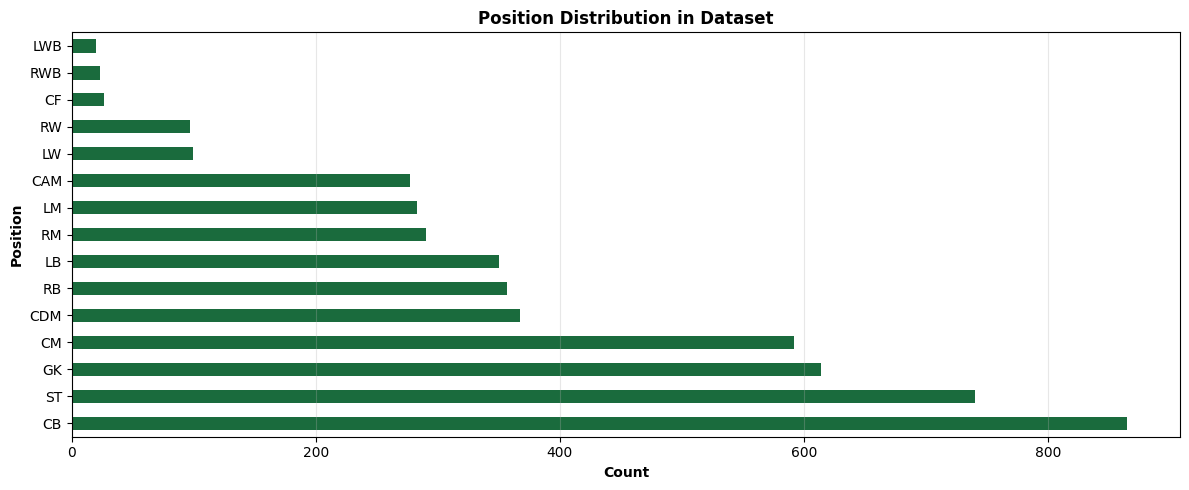

[Visualization] Total unique positions: 15


In [6]:
# Visualize position distribution
fig, ax = plt.subplots(figsize=(12, 5))
position_counts.plot(kind='barh', ax=ax, color='#1a6b3d')
ax.set_xlabel('Count', fontweight='bold')
ax.set_ylabel('Position', fontweight='bold')
ax.set_title('Position Distribution in Dataset', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"[Visualization] Total unique positions: {len(position_counts)}")

## 4. Feature Engineering

In [7]:
print("[Feature Engineering] Building feature matrix")
print()

# A. Embedding features
print("  Step 1: Extract embedding features")
X_embedding = pd.DataFrame(df['embedding'].tolist())
print(f"          Shape: {X_embedding.shape}")

# B. Statistical features from embeddings
print("  Step 2: Generate embedding statistics")
df['emb_mean'] = df['embedding'].apply(np.mean)
df['emb_std'] = df['embedding'].apply(np.std)
df['emb_max'] = df['embedding'].apply(np.max)
df['emb_min'] = df['embedding'].apply(np.min)
df['emb_range'] = df['emb_max'] - df['emb_min']
print(f"          5 statistical features added")

# C. Normalize raw stats
print("  Step 3: Normalize raw statistics")
X_stats = df[stats_cols].fillna(df[stats_cols].median())
scaler_stats = RobustScaler()
X_stats_scaled = pd.DataFrame(
    scaler_stats.fit_transform(X_stats),
    columns=stats_cols
)
print(f"          {len(stats_cols)} attributes normalized")

# D. Domain-specific features
print("  Step 4: Create domain-specific features")
df['attack_score'] = (df['finishing'] + df['dribbling'] + df['sprint_speed']) / 3
df['defense_score'] = (df['strength'] + df['stamina']) / 2
df['midfield_score'] = (df['short_passing'] + df['stamina']) / 2
df['speed_score'] = (df['acceleration'] + df['sprint_speed']) / 2
df['technical_score'] = (df['dribbling'] + df['short_passing']) / 2
print(f"          5 domain-specific features added")

# E. Aggregate features
emb_stats = df[['emb_mean', 'emb_std', 'emb_max', 'emb_min', 'emb_range']]
domain_features = df[['attack_score', 'defense_score', 'midfield_score', 
                       'speed_score', 'technical_score']]

print("  Step 5: Combine all features")
X = pd.concat([
    X_embedding.reset_index(drop=True),
    emb_stats.reset_index(drop=True),
    X_stats_scaled.reset_index(drop=True),
    domain_features.reset_index(drop=True)
], axis=1)

X.columns = X.columns.astype(str)

print(f"\n[Feature Engineering] Complete")
print(f"  Total features: {X.shape[1]}")
print(f"    - Graph embeddings: {X_embedding.shape[1]}")
print(f"    - Embedding statistics: {emb_stats.shape[1]}")
print(f"    - Normalized attributes: {len(stats_cols)}")
print(f"    - Domain-specific: {domain_features.shape[1]}")

[Feature Engineering] Building feature matrix

  Step 1: Extract embedding features
          Shape: (5000, 64)
  Step 2: Generate embedding statistics
          5 statistical features added
  Step 3: Normalize raw statistics
          8 attributes normalized
  Step 4: Create domain-specific features
          5 domain-specific features added
  Step 5: Combine all features

[Feature Engineering] Complete
  Total features: 82
    - Graph embeddings: 64
    - Embedding statistics: 5
    - Normalized attributes: 8
    - Domain-specific: 5
          5 statistical features added
  Step 3: Normalize raw statistics
          8 attributes normalized
  Step 4: Create domain-specific features
          5 domain-specific features added
  Step 5: Combine all features

[Feature Engineering] Complete
  Total features: 82
    - Graph embeddings: 64
    - Embedding statistics: 5
    - Normalized attributes: 8
    - Domain-specific: 5


In [8]:
# Encode labels
print("\n[Label Encoding] Converting position labels to numerical format")
le = LabelEncoder()
y = le.fit_transform(df['primary_position'])

print(f"\n[Label Encoding] {len(le.classes_)} unique positions:")
for i, pos in enumerate(le.classes_):
    count = (y == i).sum()
    print(f"  {pos}: {count}")


[Label Encoding] Converting position labels to numerical format

[Label Encoding] 15 unique positions:
  CAM: 277
  CB: 865
  CDM: 367
  CF: 26
  CM: 592
  GK: 614
  LB: 350
  LM: 283
  LW: 99
  LWB: 20
  RB: 357
  RM: 290
  RW: 97
  RWB: 23
  ST: 740


## 5. Data Preprocessing & Class Balancing

In [9]:
print("[Data Preprocessing] Class balance correction using SMOTE")
print()

# Check class imbalance
class_counts = pd.Series(y).value_counts()
min_class_count = class_counts.min()
max_class_count = class_counts.max()

print(f"  Before SMOTE:")
print(f"    Min class size: {min_class_count}")
print(f"    Max class size: {max_class_count}")
print(f"    Ratio: {max_class_count / min_class_count:.2f}x")

# Apply SMOTE
if min_class_count >= 6:
    print(f"\n  Applying SMOTE...")
    smote = SMOTE(random_state=42, k_neighbors=min(5, min_class_count-1))
    X_resampled, y_resampled = smote.fit_resample(X, y)
    print(f"  After SMOTE:")
    print(f"    Original: {X.shape[0]} samples")
    print(f"    Resampled: {X_resampled.shape[0]} samples")
    print(f"    Added: {X_resampled.shape[0] - X.shape[0]} samples")
else:
    print(f"\n  SMOTE skipped (smallest class: {min_class_count} samples)")
    X_resampled, y_resampled = X, y

print()

# Train-test split
print("[Data Split] Stratified train-test split")
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_resampled
)

print(f"  Train set: {X_train.shape[0]} samples")
print(f"  Test set: {X_test.shape[0]} samples")
print(f"  Ratio: {X_train.shape[0]/X_test.shape[0]:.1f}:1")

[Data Preprocessing] Class balance correction using SMOTE

  Before SMOTE:
    Min class size: 20
    Max class size: 865
    Ratio: 43.25x

  Applying SMOTE...
  After SMOTE:
    Original: 5000 samples
    Resampled: 12975 samples
    Added: 7975 samples

[Data Split] Stratified train-test split
  Train set: 10380 samples
  Test set: 2595 samples
  Ratio: 4.0:1
  After SMOTE:
    Original: 5000 samples
    Resampled: 12975 samples
    Added: 7975 samples

[Data Split] Stratified train-test split
  Train set: 10380 samples
  Test set: 2595 samples
  Ratio: 4.0:1


## 6. Model Comparison

In [10]:
print("[Model Selection] 5-Fold Stratified Cross-Validation")
print(f"  CPU cores: {joblib.cpu_count()}\n")

# Define models
models = {
    'Random Forest (Tuned)': RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    ),
    'Random Forest (Standard)': RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    'SVM': SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=7, weights='distance')
}

# Cross-validation
cv_folds = 5
results = []
names = []

for name, model in models.items():
    print(f"  Training {name}...")
    kfold = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    cv_results = cross_val_score(model, X_resampled, y_resampled, cv=kfold, scoring='accuracy')
    results.append(cv_results)
    names.append(name)
    print(f"    Mean Accuracy: {cv_results.mean():.4f} (std: {cv_results.std():.4f})")
    print(f"    Fold scores: {[f'{s:.4f}' for s in cv_results]}\n")

print("[Model Selection] Cross-validation complete")

[Model Selection] 5-Fold Stratified Cross-Validation
  CPU cores: 16

  Training Random Forest (Tuned)...
    Mean Accuracy: 0.9227 (std: 0.0065)
    Fold scores: ['0.9279', '0.9171', '0.9202', '0.9326', '0.9156']

  Training Random Forest (Standard)...
    Mean Accuracy: 0.9227 (std: 0.0065)
    Fold scores: ['0.9279', '0.9171', '0.9202', '0.9326', '0.9156']

  Training Random Forest (Standard)...
    Mean Accuracy: 0.9299 (std: 0.0077)
    Fold scores: ['0.9403', '0.9198', '0.9279', '0.9372', '0.9241']

  Training SVM...
    Mean Accuracy: 0.9299 (std: 0.0077)
    Fold scores: ['0.9403', '0.9198', '0.9279', '0.9372', '0.9241']

  Training SVM...
    Mean Accuracy: 0.5689 (std: 0.0060)
    Fold scores: ['0.5703', '0.5688', '0.5626', '0.5792', '0.5634']

  Training KNN...
    Mean Accuracy: 0.5689 (std: 0.0060)
    Fold scores: ['0.5703', '0.5688', '0.5626', '0.5792', '0.5634']

  Training KNN...
    Mean Accuracy: 0.8400 (std: 0.0061)
    Fold scores: ['0.8428', '0.8493', '0.8408', '0

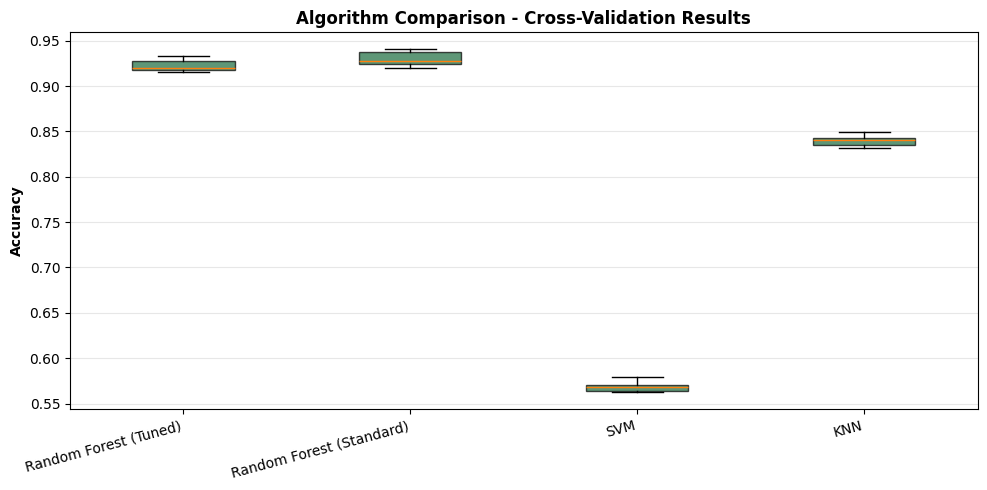

[Visualization] Model comparison plot displayed


In [11]:
# Visualize model comparison
fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot(results, labels=names, patch_artist=True)

for patch in bp['boxes']:
    patch.set_facecolor('#1a6b3d')
    patch.set_alpha(0.7)

ax.set_ylabel('Accuracy', fontweight='bold')
ax.set_title('Algorithm Comparison - Cross-Validation Results', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

print("[Visualization] Model comparison plot displayed")

## 7. Hyperparameter Tuning

In [12]:
print("[Hyperparameter Tuning] GridSearchCV on Random Forest\n")

# Parameter grid
param_grid = {
    'n_estimators': [150, 200, 250],
    'max_depth': [15, 20, 25],
    'min_samples_split': [3, 5, 7],
    'min_samples_leaf': [1, 2, 3],
    'max_features': ['sqrt', 'log2']
}

print("Parameter search space:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")

total_combos = np.prod([len(v) for v in param_grid.values()])
print(f"\nTotal combinations: {total_combos}")
print(f"Cross-validation folds: 5\n")

# Grid search
print("Executing grid search...")
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(
    rf_base, 
    param_grid, 
    cv=5, 
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

start_tune = time.time()
grid_search.fit(X_train, y_train)
tune_time = time.time() - start_tune

print(f"\n[Hyperparameter Tuning] Completed in {tune_time:.1f} seconds\n")
print(f"Best hyperparameters:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest CV accuracy: {grid_search.best_score_:.4f}")

[Hyperparameter Tuning] GridSearchCV on Random Forest

Parameter search space:
  n_estimators: [150, 200, 250]
  max_depth: [15, 20, 25]
  min_samples_split: [3, 5, 7]
  min_samples_leaf: [1, 2, 3]
  max_features: ['sqrt', 'log2']

Total combinations: 162
Cross-validation folds: 5

Executing grid search...
Fitting 5 folds for each of 162 candidates, totalling 810 fits

[Hyperparameter Tuning] Completed in 1916.4 seconds

Best hyperparameters:
  max_depth: 20
  max_features: sqrt
  min_samples_leaf: 1
  min_samples_split: 3
  n_estimators: 250

Best CV accuracy: 0.9203

[Hyperparameter Tuning] Completed in 1916.4 seconds

Best hyperparameters:
  max_depth: 20
  max_features: sqrt
  min_samples_leaf: 1
  min_samples_split: 3
  n_estimators: 250

Best CV accuracy: 0.9203


## 8. Final Model Evaluation

In [13]:
print("[Model Evaluation] Final Random Forest Performance\n")

# Get best model
final_model = grid_search.best_estimator_

# Make predictions
y_pred = final_model.predict(X_test)
test_score = final_model.score(X_test, y_test)

print(f"Test Set Accuracy: {test_score:.4f}")
print(f"Best CV Accuracy: {grid_search.best_score_:.4f}\n")

# Classification report
print("Classification Report:")
print("-" * 70)
print(classification_report(y_test, y_pred, target_names=le.classes_, digits=4))

[Model Evaluation] Final Random Forest Performance

Test Set Accuracy: 0.9256
Best CV Accuracy: 0.9203

Classification Report:
----------------------------------------------------------------------
              precision    recall  f1-score   support

         CAM     0.8632    0.9480    0.9036       173
          CB     0.9245    0.8497    0.8855       173
         CDM     0.8216    0.8786    0.8492       173
          CF     0.9774    1.0000    0.9886       173
          CM     0.8851    0.7572    0.8162       173
          GK     1.0000    1.0000    1.0000       173
          LB     0.8883    0.9653    0.9252       173
          LM     0.8895    0.8844    0.8870       173
          LW     0.9297    0.9942    0.9609       173
         LWB     0.9886    1.0000    0.9943       173
          RB     0.8908    0.8960    0.8934       173
          RM     0.9506    0.8902    0.9194       173
          RW     0.9709    0.9653    0.9681       173
         RWB     0.9943    1.0000    0.9971  


[Model Interpretation] Top 15 Most Important Features

   1. finishing            0.0447
   2. attack_score         0.0359
   3. dribbling            0.0257
   4. midfield_score       0.0239
   5. short_passing        0.0216
   6. technical_score      0.0211
   7. speed_score          0.0205
   8. stamina              0.0205
   9. strength             0.0188
  10. acceleration         0.0182
  11. defense_score        0.0176
  12. sprint_speed         0.0172
  13. emb_std              0.0166
  14. emb_32               0.0154
  15. emb_17               0.0137


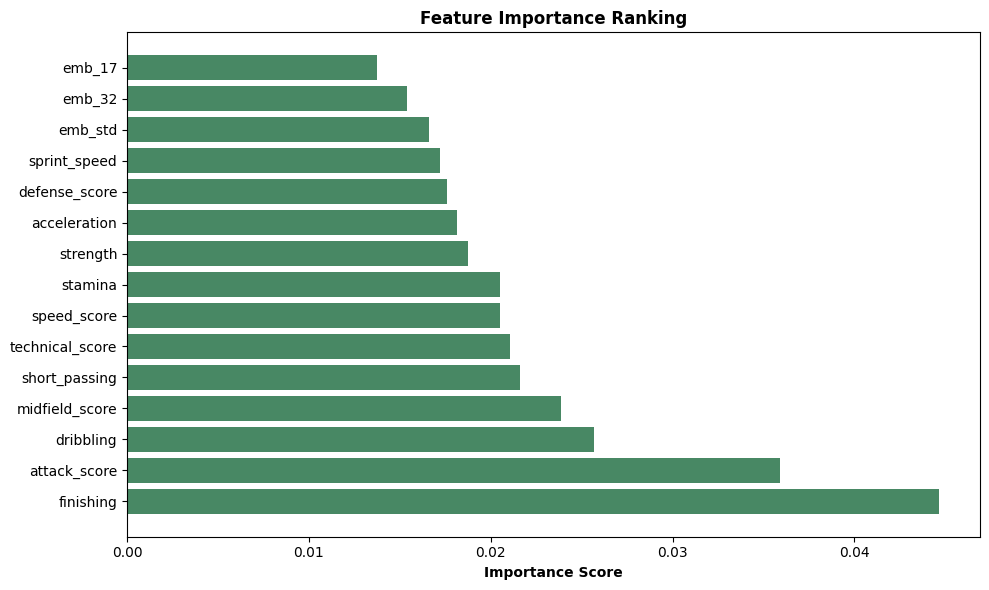


[Visualization] Feature importance plot displayed


In [14]:
# Feature importance
print("\n[Model Interpretation] Top 15 Most Important Features\n")

feature_names = (
    [f'emb_{i}' for i in range(X_embedding.shape[1])] +
    ['emb_mean', 'emb_std', 'emb_max', 'emb_min', 'emb_range'] +
    stats_cols +
    ['attack_score', 'defense_score', 'midfield_score', 'speed_score', 'technical_score']
)

importances = final_model.feature_importances_
indices = np.argsort(importances)[-15:]

for rank, idx in enumerate(reversed(indices), 1):
    print(f"  {rank:2d}. {feature_names[idx]:20s} {importances[idx]:.4f}")

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(indices)), importances[indices], color='#1a6b3d', alpha=0.8)
ax.set_yticks(range(len(indices)))
ax.set_yticklabels([feature_names[i] for i in indices])
ax.set_xlabel('Importance Score', fontweight='bold')
ax.set_title('Feature Importance Ranking', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\n[Visualization] Feature importance plot displayed")

## 9. Model and Artifact Storage

In [15]:
print("\n[Model Persistence] Saving trained artifacts\n")

# Save model
print("  Saving Random Forest classifier...")
model_filename = 'best_football_model.pkl'
joblib.dump(final_model, model_filename)
print(f"    Saved to: {model_filename}")

# Save label encoder
print("  Saving label encoder...")
le_filename = 'label_encoder.pkl'
joblib.dump(le, le_filename)
print(f"    Saved to: {le_filename}")

# Save scaler
print("  Saving feature scaler...")
scaler_filename = 'scaler.pkl'
joblib.dump(scaler_stats, scaler_filename)
print(f"    Saved to: {scaler_filename}")

# Save feature configuration
print("  Saving model configuration...")
feature_config = {
    'n_embedding_features': X_embedding.shape[1],
    'stats_cols': stats_cols,
    'use_smote': True,
    'model_type': 'RandomForestClassifier',
    'test_accuracy': float(test_score),
    'cv_accuracy': float(grid_search.best_score_),
    'best_params': grid_search.best_params_,
    'positions': le.classes_.tolist(),
    'feature_engineering': {
        'embedding_stats': True,
        'normalized_stats': True,
        'domain_features': True
    }
}

config_filename = 'model_config.json'
with open(config_filename, 'w') as f:
    json.dump(feature_config, f, indent=2)
print(f"    Saved to: {config_filename}")

print("\n[Model Persistence] Complete - Ready for deployment")
print(f"\nModel Summary:")
print(f"  Test Accuracy: {test_score:.4f}")
print(f"  CV Accuracy: {grid_search.best_score_:.4f}")
print(f"  Total Features: {X.shape[1]}")
print(f"  Positions: {len(le.classes_)}")


[Model Persistence] Saving trained artifacts

  Saving Random Forest classifier...
    Saved to: best_football_model.pkl
  Saving label encoder...
    Saved to: label_encoder.pkl
  Saving feature scaler...
    Saved to: scaler.pkl
  Saving model configuration...
    Saved to: model_config.json

[Model Persistence] Complete - Ready for deployment

Model Summary:
  Test Accuracy: 0.9256
  CV Accuracy: 0.9203
  Total Features: 82
  Positions: 15
    Saved to: best_football_model.pkl
  Saving label encoder...
    Saved to: label_encoder.pkl
  Saving feature scaler...
    Saved to: scaler.pkl
  Saving model configuration...
    Saved to: model_config.json

[Model Persistence] Complete - Ready for deployment

Model Summary:
  Test Accuracy: 0.9256
  CV Accuracy: 0.9203
  Total Features: 82
  Positions: 15
